# Word Clouds for Text Product Categories

## 📌Objectives of the Notebook

In this notebook, we will explore and visualize the text data associated with product codes using Word Clouds. This will help us better understand the most frequent words for each category and identify potential patterns.

## Key Steps:
✔ **Loading pre-cleaned text data**  → Import processed datasets (`X_train_cleaned.pkl` & `X_test_sub_cleaned.pkl`).       
✔  **Generating and visualizing Word Clouds** → Extract and display the most frequent words for each product category.   
✔  **Identifying Product Category Labels from Word Cloud Analysis**    
✔  **Mapping product codes to labels** → Assign descriptive category names to product codes for better interpretability.  
✔  **Saving the labeled dataset** → Store the final processed data (`X_train_labeled.pkl) for future use.


## 1. Import Required Libraries 

In [48]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
import os
from pathlib import Path
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
import matplotlib  
import importlib
%matplotlib inline

### Setting Up Project Paths and Configurations

In [49]:
# Get the current notebook directory
CURRENT_DIR = Path(os.getcwd()).resolve()

# Automatically find the project root (go up 1 level)
PROJECT_ROOT = CURRENT_DIR.parents[1]

# Add project root to sys.path
sys.path.append(str(PROJECT_ROOT))

# Function to get relative paths from project root
def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

# Print project root directory
print(f"Project Root Directory: {PROJECT_ROOT.name}")  # Display only the root folder name

import config  # Now Python can find config.py

Project Root Directory: Data_Scientist_Rakuten_Project-main


## 2. Load Pickle Files (X_test_cleaned.pkl & X_test_cleaned.pkl)

In [50]:
importlib.reload(config)  # Reload config to ensure any updates are applied

# Define paths for datasets (FILES, not directories)
train_pickle_path = Path(config.INTERIM_DIR) / "X_train_cleaned.pkl"
test_pickle_path = Path(config.INTERIM_DIR) / "X_test_sub_cleaned.pkl"
y_train_pickle_path = Path(config.INTERIM_DIR) / "y_train.pkl"

# Function to get relative paths from project root
def get_relative_path(absolute_path: Path):
    """Returns the relative path from the project root."""
    return str(absolute_path.relative_to(config.BASE_DIR))

# Function to load a Pickle file safely
def load_pickle(file_path: Path, dataset_name: str):
    """Loads a pickle file with error handling and basic visualization."""
    if not file_path.exists():
        print(f"Error: `{dataset_name}` file not found at {file_path}")
        return None

    try:
        data = pd.read_pickle(file_path)
        print(f"Successfully loaded `{dataset_name}` | Shape: {data.shape}")

        if not data.empty:
            display(data.head())  # Display first rows

        return data
    except Exception as e:
        print(f"Error loading `{dataset_name}`: {e}")
        return None

# List of required files with their names
required_files = {
    "Training Dataset": train_pickle_path,
    "Testing Dataset": test_pickle_path,   
    "Training Labels": y_train_pickle_path
}

# Check if files exist before loading
for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Error: `{name}` file not found at {get_relative_path(path)}")

# Load datasets
X_train = load_pickle(train_pickle_path, "X_train_cleaned.pkl")
X_test_sub = load_pickle(test_pickle_path, "X_test_sub_cleaned.pkl")
y_train = load_pickle(y_train_pickle_path, "y_train.pkl")


Successfully loaded `X_train_cleaned.pkl` | Shape: (84916, 7)


,designation,description,productid,imageid,prdtypecode,image_name,text
0,olivia personalisiertes notizbuch seiten punkt...,NaN,3804725264,1263597046,10,image_1263597046_product_3804725264.jpg,olivia personalisiertes notizbuch seiten punkt...
1,journal arts art marche salon art asiatique pa...,NaN,436067568,1008141237,2280,image_1008141237_product_436067568.jpg,journal arts art marche salon asiatique paris ...
2,grand stylet ergonomique bleu gamepad nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,image_938777978_product_201115110.jpg,grand stylet ergonomique bleu gamepad nintendo...
3,peluche donald europe disneyland marionnette d...,NaN,50418756,457047496,1280,image_457047496_product_50418756.jpg,peluche donald europe disneyland marionnette d...
4,guerre tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,image_1077757786_product_278535884.jpg,guerre tuques luc idees grandeur veut organise...


Successfully loaded `X_test_sub_cleaned.pkl` | Shape: (13812, 6)


,designation,description,productid,imageid,image_name,text
84916,folkmanis puppets marionnette theatre mini turtle,NaN,516376098,1019294171,image_1019294171_product_516376098.jpg,folkmanis puppets marionnette theatre mini turtle
84917,porte flamme gaxix flamebringer gaxix twilight...,NaN,133389013,1274228667,image_1274228667_product_133389013.jpg,porte flamme gaxix flamebringer twilight dragons
84918,pompe filtration speck badu,NaN,4128438366,1295960357,image_1295960357_product_4128438366.jpg,pompe filtration speck badu
84919,robot piscine electrique,<p>Ce robot de piscine d&#39;un design innovan...,3929899732,1265224052,image_1265224052_product_3929899732.jpg,robot piscine electrique design innovant elega...
84920,hsm destructeur securio coupe croise,NaN,152993898,940543690,image_940543690_product_152993898.jpg,hsm destructeur securio coupe croise


Successfully loaded `y_train.pkl` | Shape: (84916, 1)


,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705


## 3. Generating and Visualizing Word Clouds

Word Clouds help us quickly identify the most frequent words in each product category. This can provide insights into key terms associated with different categories.

### 3.1  Import Required Libraries

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 3.2 Get unique product code values

In [52]:
import numpy as np

# === Get unique product codes === #
unique_product_codes = np.unique(X_train["prdtypecode"])

# Display unique values
print("Unique Product Codes:")
print(unique_product_codes)


Unique Product Codes:
[  10   40   50   60 1140 1160 1180 1280 1281 1300 1301 1302 1320 1560
 1920 1940 2060 2220 2280 2403 2462 2522 2582 2583 2585 2705 2905]


### 3.3 Define a Function to Generate Word Clouds

In [53]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Global dictionary to store top words per category
word_freq_dict = {}

def plot_wordcloud(category, data, column="text"):
    """
    Generate and display a Word Cloud for a given product category,
    and store the most frequent words in a global dictionary.

    Parameters:
    - category (int): The product category code to visualize.
    - data (DataFrame): The dataset containing text data.
    - column (str): The column containing the text (default: "text").
    """
    text_data = " ".join(data[data["prdtypecode"] == category][column].dropna())
    
    # Generate the Word Cloud
    wc = WordCloud(
        background_color="black",  # Set background color to black for better contrast
        max_words=100,             # Limit the number of words displayed in the Word Cloud
        max_font_size=50,          # Set the maximum font size for the largest words
        random_state=42            # Ensure reproducibility
    ).generate(text_data)

    # Extract most frequent words
    word_frequencies = wc.words_  # Dictionary {word: frequency}
    top_words = Counter(word_frequencies).most_common(10)  # Get top 10 words

    # Store in global dictionary
    word_freq_dict[category] = top_words

    # Print most frequent words for the category
    print(f"\n Most frequent words for category {category}:")
    for word, freq in top_words:
        print(f"   {word}: {freq:.4f}")

    # Display the Word Cloud
    plt.figure(figsize=(15, 15))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {category}", fontsize=14)
    plt.show()


### 3.4 Generating Word Clouds for All Product Code Categories


 Most frequent words for category 10:
   tome: 1.0000
   edition: 0.8155
   histoire: 0.6250
   guide: 0.5357
   collection: 0.4107
   book: 0.4048
   vie: 0.3988
   france: 0.3929
   art: 0.3333
   volume: 0.2857


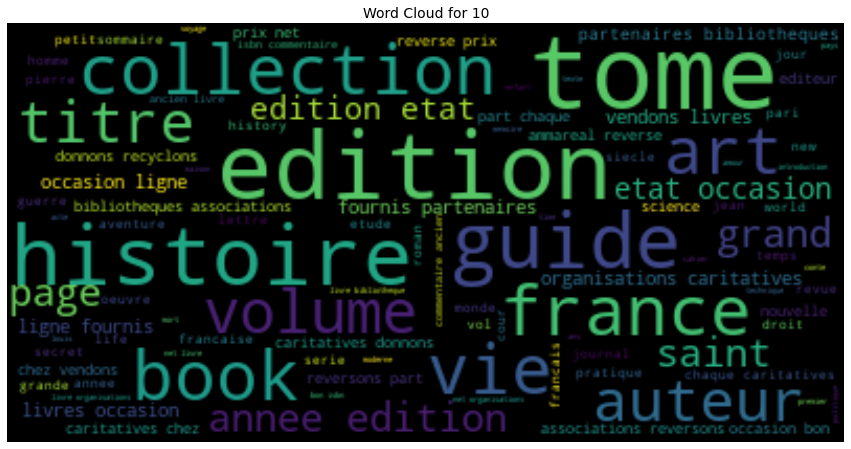

In [54]:
plot_wordcloud(10, X_train)



 Most frequent words for category 40:
   forfait comprend: 1.0000
   attention produit: 0.9000
   produit informations: 0.9000
   informations langues: 0.9000
   langues titres: 0.9000
   titres apparaissent: 0.9000
   apparaissent fiche: 0.9000
   fiche editeur: 0.9000
   editeur fournies: 0.9000
   fournies neanmoins: 0.9000


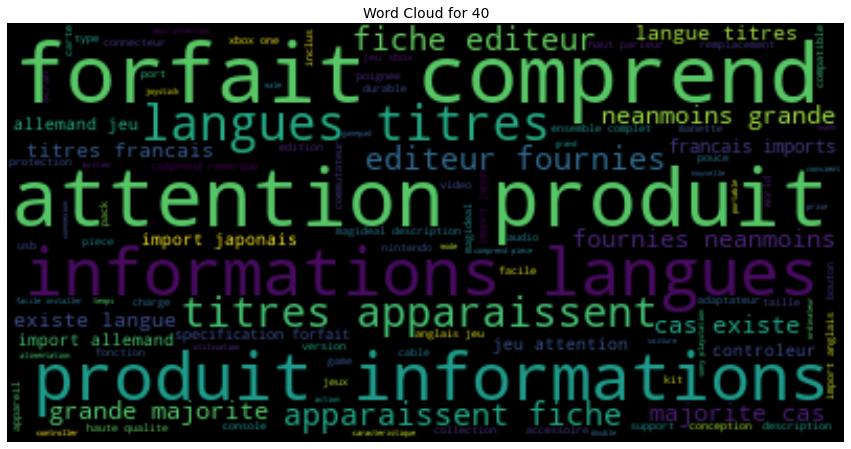

In [55]:
plot_wordcloud(40, X_train)



 Most frequent words for category 50:
   manette: 1.0000
   controleur: 0.9104
   jeu: 0.8918
   support: 0.8657
   console: 0.8545
   compatible: 0.8358
   cable: 0.8097
   usb: 0.7724
   charge: 0.7015
   haute qualite: 0.6231


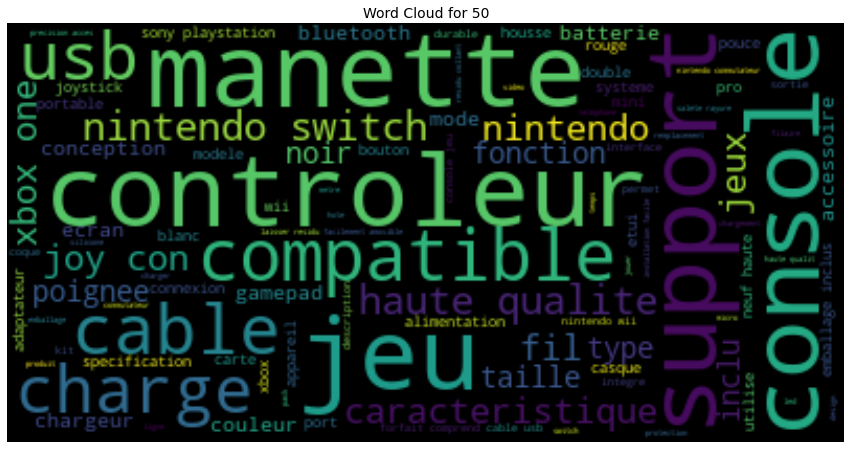

In [56]:
plot_wordcloud(50, X_train)



 Most frequent words for category 60:
   console jeu: 1.0000
   nom marque: 0.8471
   ouiecran tactile: 0.8107
   denumero modele: 0.5437
   couleur ouiecran: 0.5388
   tactile denumero: 0.5364
   affichage couleur: 0.5194
   ouitaille ecran: 0.5170
   couleur ouitaille: 0.4976
   numero modele: 0.4927


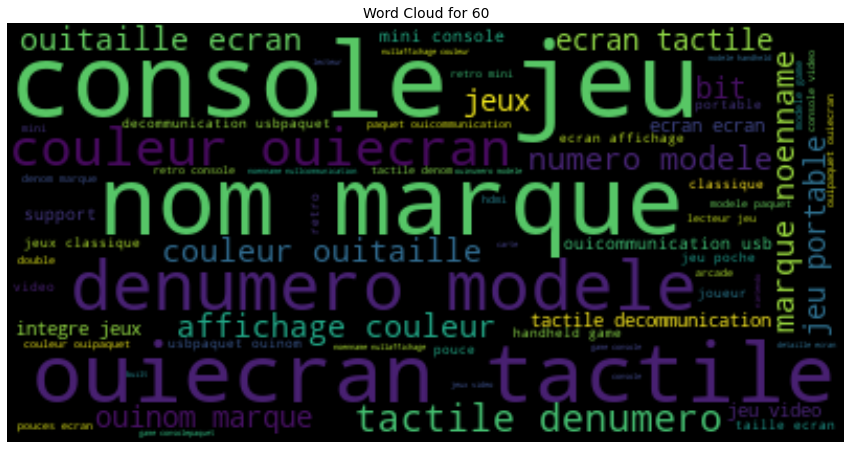

In [57]:
plot_wordcloud(60, X_train)



 Most frequent words for category 1140:
   figurine: 1.0000
   star wars: 0.2484
   serie: 0.1991
   collection: 0.1696
   licence officielle: 0.1565
   haute qualite: 0.1521
   taille env: 0.1433
   figurine pop: 0.1357
   shirt: 0.1225
   funko pop: 0.0919


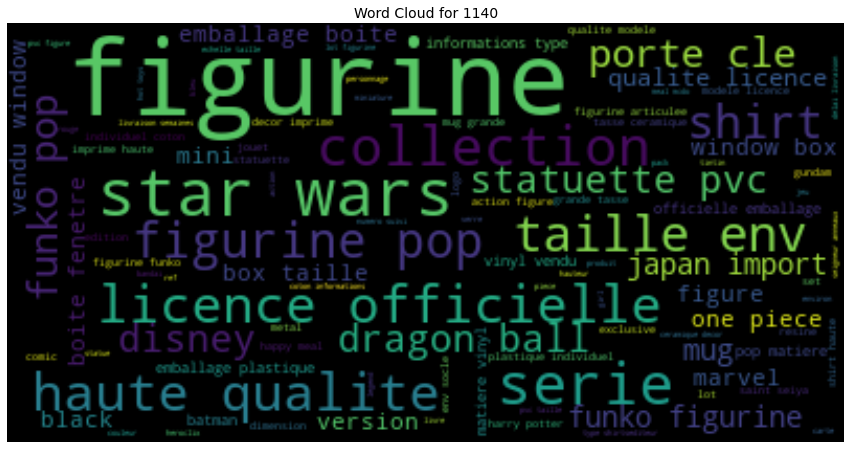

In [58]:
plot_wordcloud(1140, X_train)



 Most frequent words for category 1160:
   carte: 1.0000
   magic mtg: 0.6562
   commune: 0.5639
   carte pokemon: 0.5619
   dragon ball: 0.3733
   rare: 0.3674
   pokemon: 0.2692
   neuf: 0.2141
   magic: 0.1906
   reverse: 0.1866


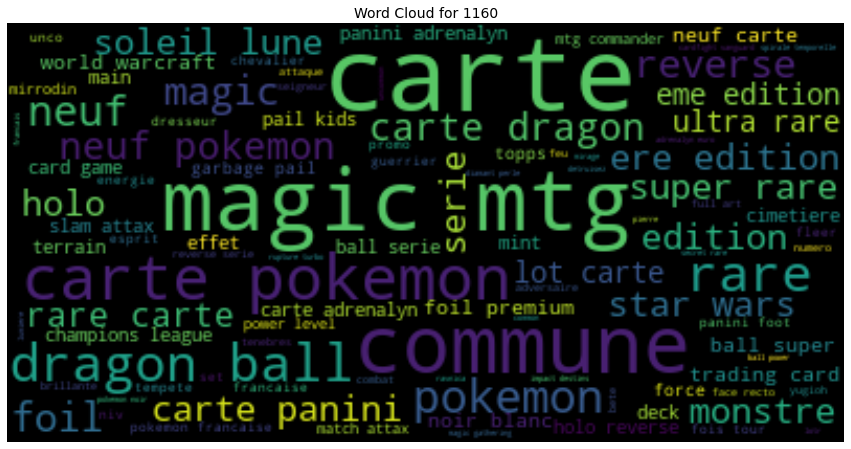

In [59]:
plot_wordcloud(1160, X_train)



 Most frequent words for category 1180:
   warhammer: 1.0000
   figurine: 0.7978
   heroclix: 0.7865
   jeu: 0.4831
   masque: 0.3933
   prince august: 0.3820
   carte: 0.3596
   metal: 0.3371
   jeux role: 0.3034
   miniature: 0.2921


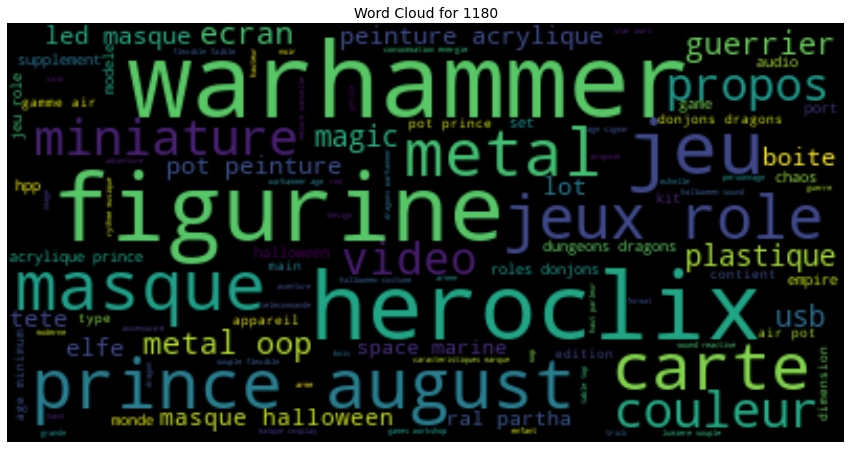

In [60]:
plot_wordcloud(1180, X_train)



 Most frequent words for category 1280:
   jouet: 1.0000
   enfant: 0.6715
   haute qualite: 0.5683
   modele: 0.4061
   toy: 0.4053
   caracteristique: 0.3933
   forfait comprend: 0.3805
   neuf haute: 0.3720
   poupee: 0.3567
   piece: 0.3567


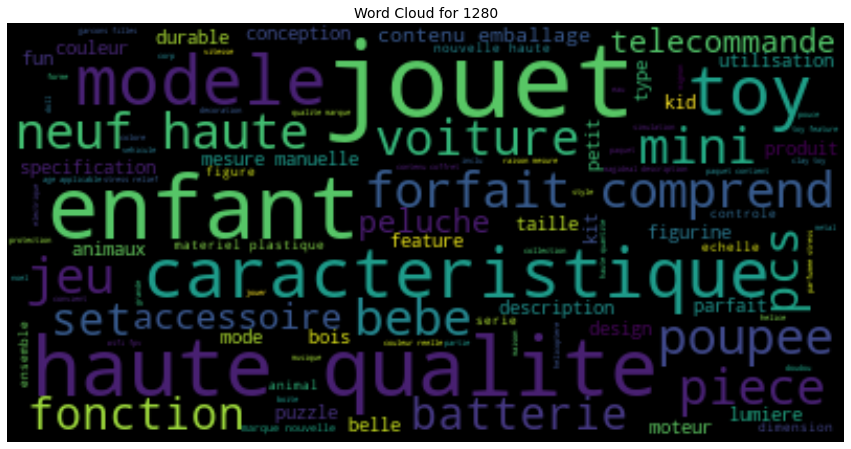

In [61]:
plot_wordcloud(1280, X_train)



 Most frequent words for category 1281:
   jouet: 1.0000
   enfant: 0.9650
   jeu: 0.9503
   carte: 0.4622
   bebe: 0.4365
   game: 0.3904
   card: 0.3554
   haute qualite: 0.3315
   toy: 0.3278
   caracteristique: 0.3204


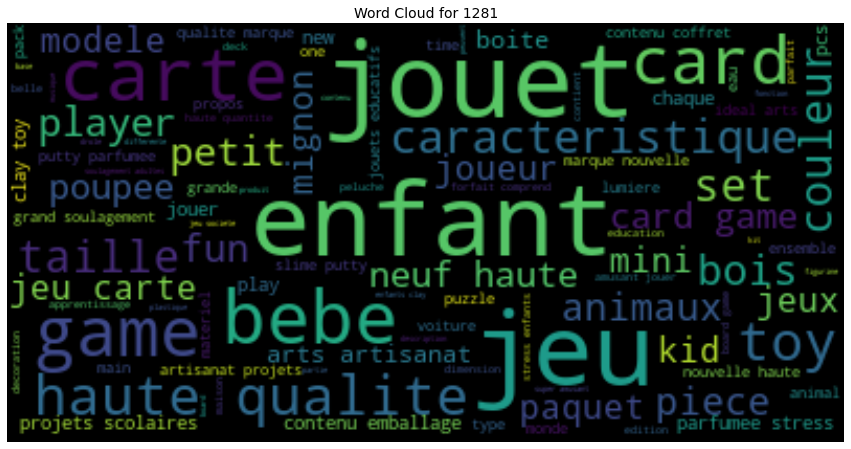

In [62]:
plot_wordcloud(1281, X_train)



 Most frequent words for category 1300:
   haute qualite: 1.0000
   dji mavic: 0.7722
   wifi fpv: 0.7435
   telecommande: 0.7340
   caracteristique: 0.6248
   type: 0.6085
   batterie: 0.5935
   fonction: 0.5935
   maquette avion: 0.5853
   forfait comprend: 0.5593


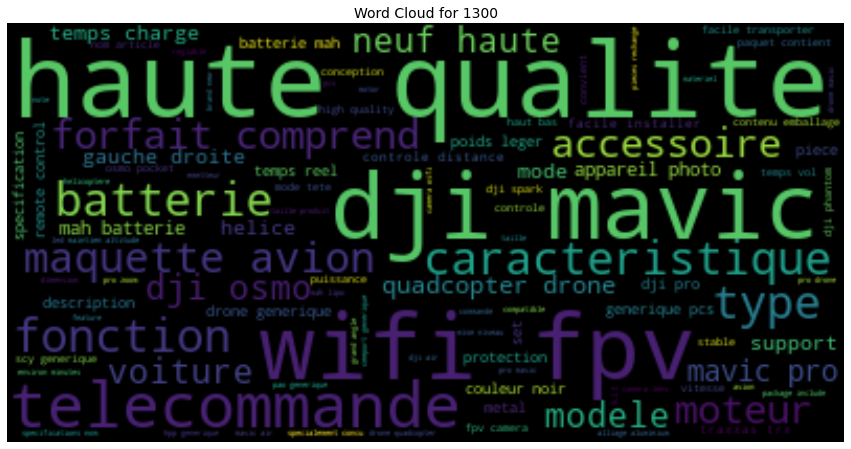

In [63]:
plot_wordcloud(1300, X_train)



 Most frequent words for category 1301:
   haute qualite: 1.0000
   anti slip: 0.9112
   materiaux haute: 0.7829
   grand cadeau: 0.7171
   mal peau: 0.6382
   sentiment main: 0.6217
   main molle: 0.6217
   cadeau sexe: 0.6184
   filles garcons: 0.6184
   disponible gardez: 0.6151


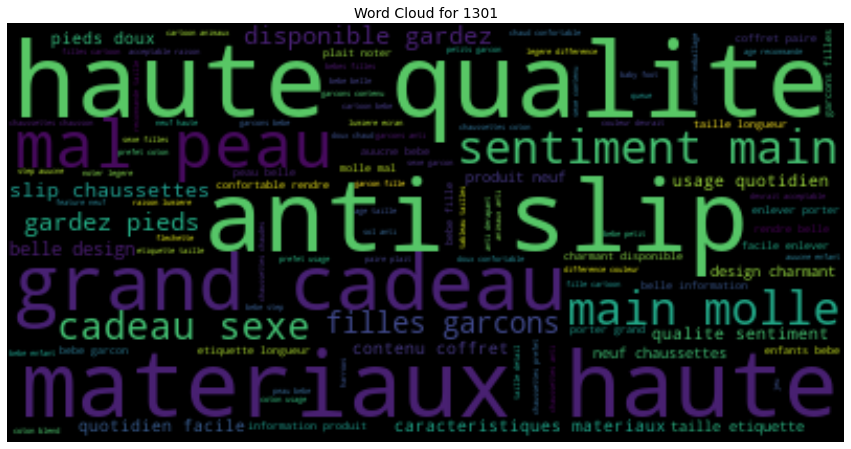

In [64]:
plot_wordcloud(1301, X_train)



 Most frequent words for category 1302:
   haute qualite: 1.0000
   neuf haute: 0.9531
   plein air: 0.8938
   stream: 0.8469
   mode: 0.7250
   enfant: 0.6844
   exterieur: 0.6438
   mauvais sentiments: 0.6406
   lumiere: 0.6344
   age applicable: 0.6281


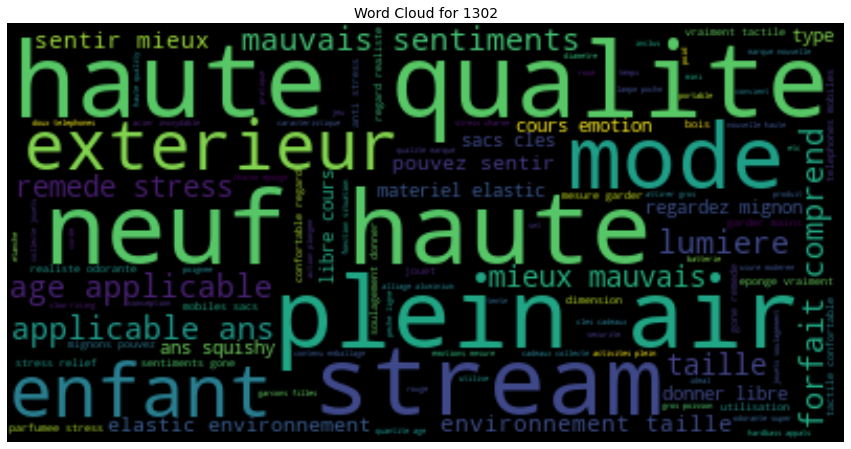

In [65]:
plot_wordcloud(1302, X_train)



 Most frequent words for category 1320:
   bebe: 1.0000
   enfant: 0.6552
   haute qualite: 0.3599
   bavoir bebe: 0.3599
   rose: 0.3571
   petit: 0.3516
   bebe imprime: 0.3132
   moniteurs image: 0.2995
   image refleter: 0.2995
   type style: 0.2981


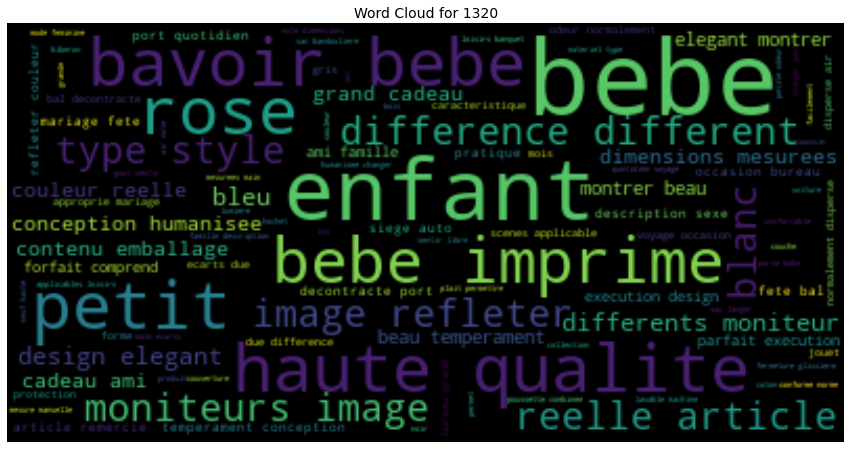

In [66]:
plot_wordcloud(1320, X_train)



 Most frequent words for category 1560:
   haute qualite: 1.0000
   design: 0.7907
   class hps: 0.7845
   taille: 0.5401
   neuf haute: 0.5125
   chaise: 0.4937
   blanc: 0.4862
   pratique: 0.4787
   etagere: 0.4787
   porte: 0.4674


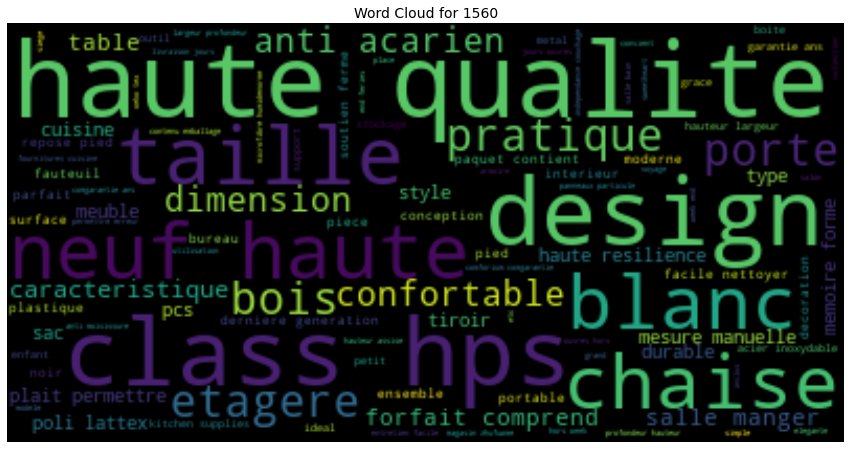

In [67]:
plot_wordcloud(1560, X_train)



 Most frequent words for category 1920:
   home decor: 1.0000
   taie oreiller: 0.8405
   haute qualite: 0.7118
   plait permettre: 0.7068
   neuf haute: 0.5623
   forfait comprend: 0.5247
   permettre legere: 0.4998
   legere deviation: 0.4250
   couleur mesure: 0.4146
   deviation couleur: 0.4132


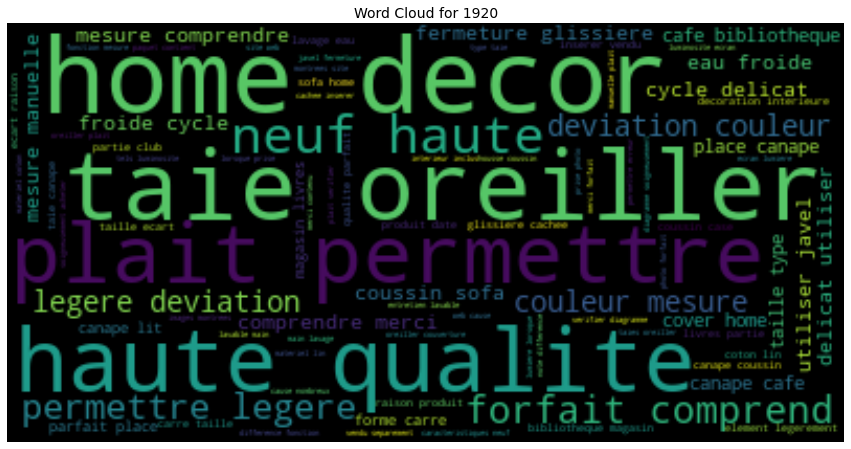

In [68]:
plot_wordcloud(1920, X_train)



 Most frequent words for category 1940:
   bio: 1.0000
   cafe: 0.9106
   lait: 0.4804
   sucre: 0.4637
   gout: 0.4413
   saveur: 0.4134
   arome: 0.4022
   boite: 0.4022
   type produit: 0.3911
   pate: 0.3855


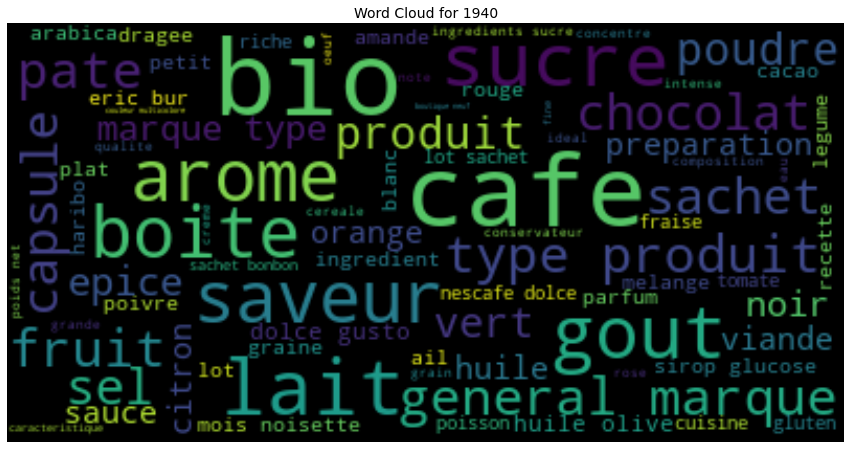

In [69]:
plot_wordcloud(1940, X_train)



 Most frequent words for category 2060:
   haute qualite: 1.0000
   forfait comprend: 0.9042
   neuf haute: 0.6429
   led: 0.6294
   home decor: 0.5109
   contenu emballage: 0.4857
   lumiere: 0.4311
   salle bain: 0.3966
   plait permettre: 0.3899
   lampe: 0.3807


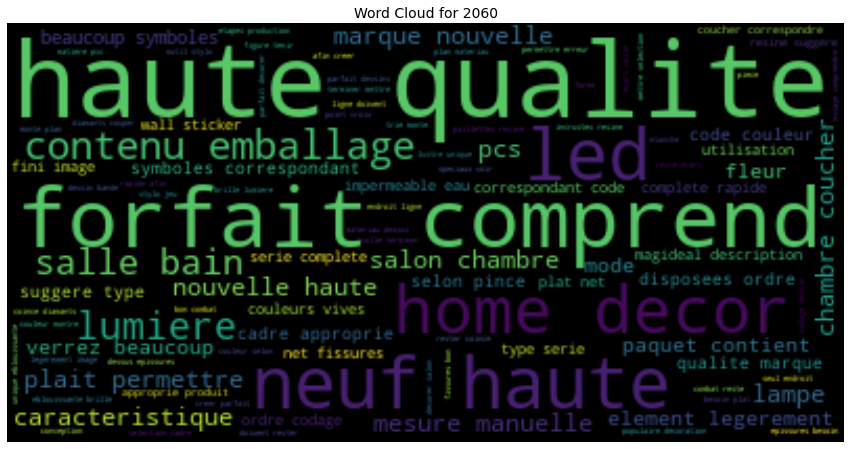

In [70]:
plot_wordcloud(2060, X_train)



 Most frequent words for category 2220:
   chien: 1.0000
   pet: 0.4502
   taille: 0.3571
   forfait comprend: 0.3506
   jouet: 0.3355
   chien chat: 0.3160
   chat: 0.2900
   animal compagnie: 0.2835
   haute qualite: 0.2662
   animaux: 0.2576


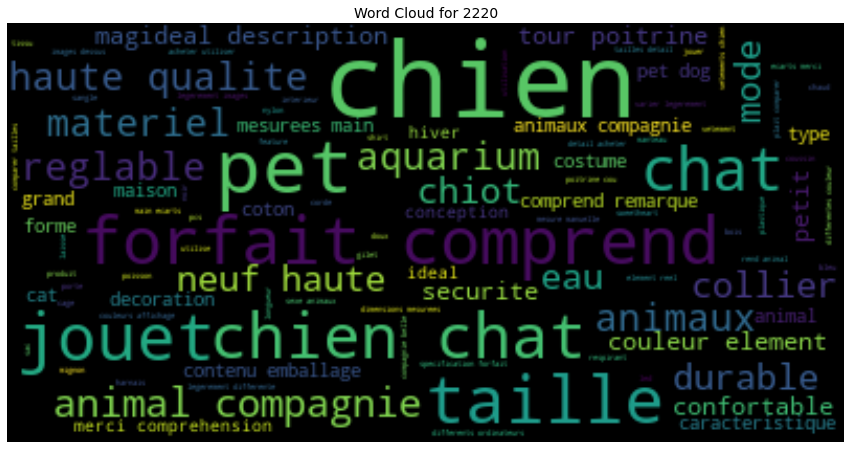

In [71]:
plot_wordcloud(2220, X_train)



 Most frequent words for category 2280:
   france: 1.0000
   pari: 0.9160
   monde: 0.7280
   magazine: 0.7080
   revue: 0.5760
   jean: 0.5600
   nouvelle: 0.5000
   histoire: 0.4560
   guerre: 0.4440
   art: 0.4000


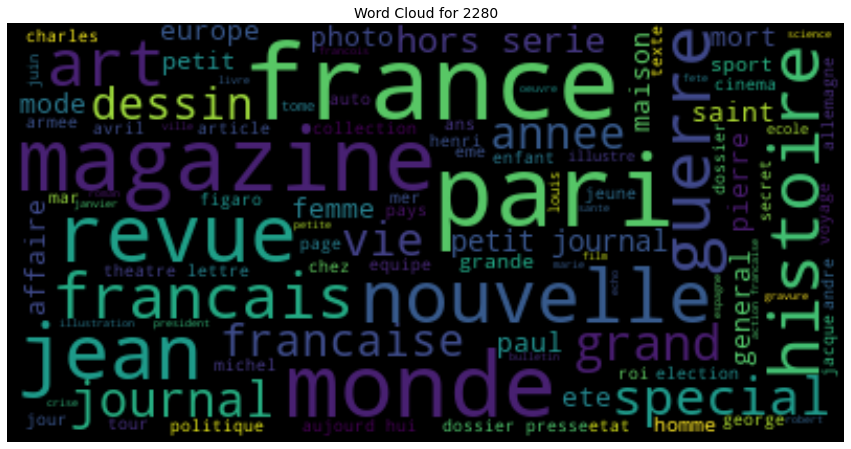

In [72]:
plot_wordcloud(2280, X_train)



 Most frequent words for category 2403:
   lot livre: 1.0000
   lot: 0.9351
   tome: 0.8386
   edition: 0.5475
   volume: 0.4661
   collection: 0.3333
   livres partitions: 0.3122
   annee: 0.2866
   lot revue: 0.2730
   histoire: 0.2187


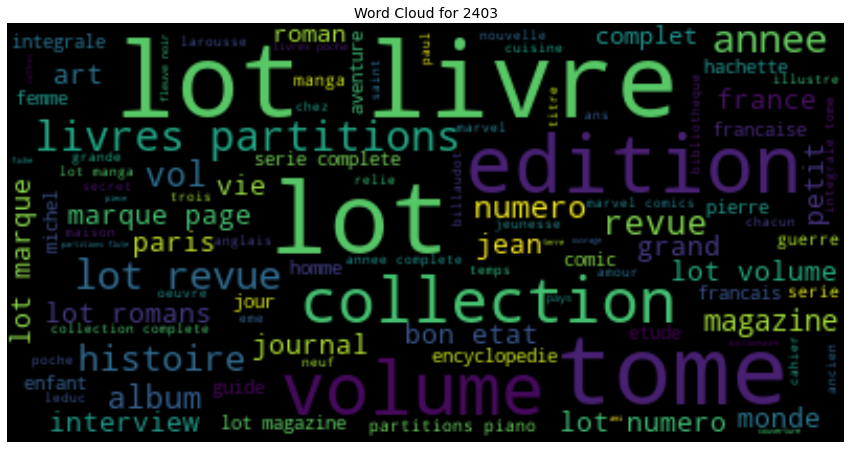

In [73]:
plot_wordcloud(2403, X_train)



 Most frequent words for category 2462:
   jeux: 1.0000
   lot: 0.7832
   console: 0.5265
   voir photo: 0.5221
   playstation: 0.5177
   jeu neuf: 0.5044
   neuf voir: 0.5044
   nintendo: 0.4956
   manette: 0.4823
   lot jeux: 0.4248


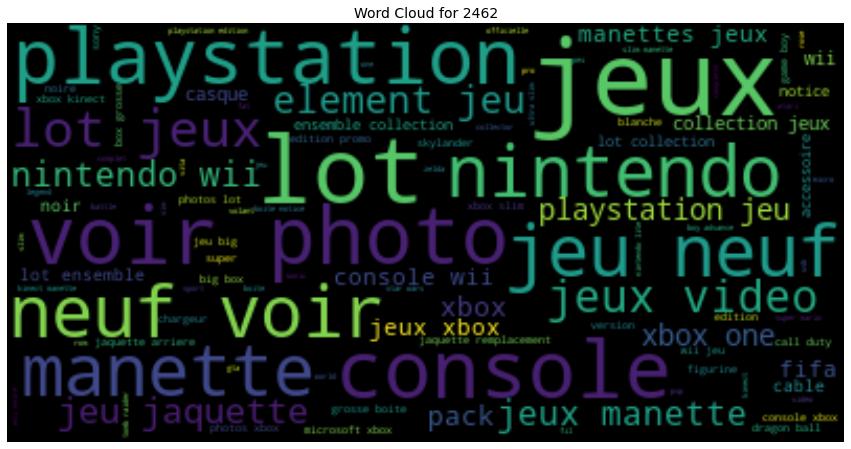

In [74]:
plot_wordcloud(2462, X_train)



 Most frequent words for category 2522:
   recto verso: 1.0000
   carnet note: 1.0000
   notes bloc: 0.9846
   taille format: 0.9730
   solide design: 0.9730
   design pages: 0.9730
   verso texture: 0.9730
   pale recto: 0.9717
   couverture solide: 0.9666
   pages jaune: 0.9537


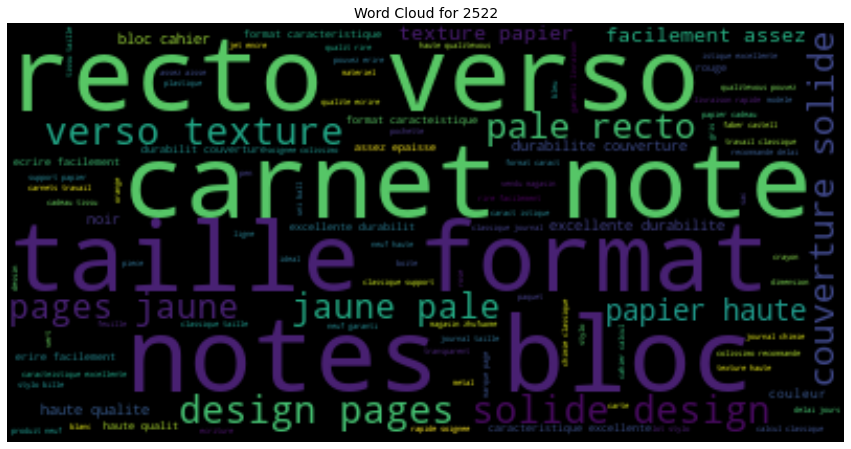

In [75]:
plot_wordcloud(2522, X_train)



 Most frequent words for category 2582:
   exterieur: 1.0000
   taille: 0.8226
   table: 0.8000
   haute qualite: 0.7226
   chaise: 0.6548
   high quality: 0.6452
   coussin: 0.6419
   stainless steel: 0.6419
   dimension: 0.6323
   bois: 0.6161


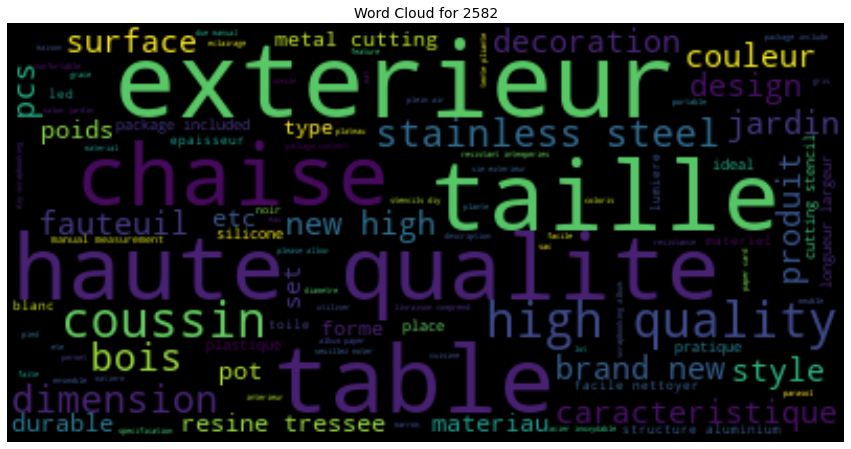

In [76]:
plot_wordcloud(2582, X_train)



 Most frequent words for category 2583:
   hors sol: 1.0000
   kit piscine: 0.5802
   dimensions exterieures: 0.5537
   volume eau: 0.4453
   tapis sol: 0.4244
   exterieures interieures: 0.3878
   echelle securite: 0.3562
   filtration sable: 0.3501
   piscine hors: 0.3440
   garantie ans: 0.3394


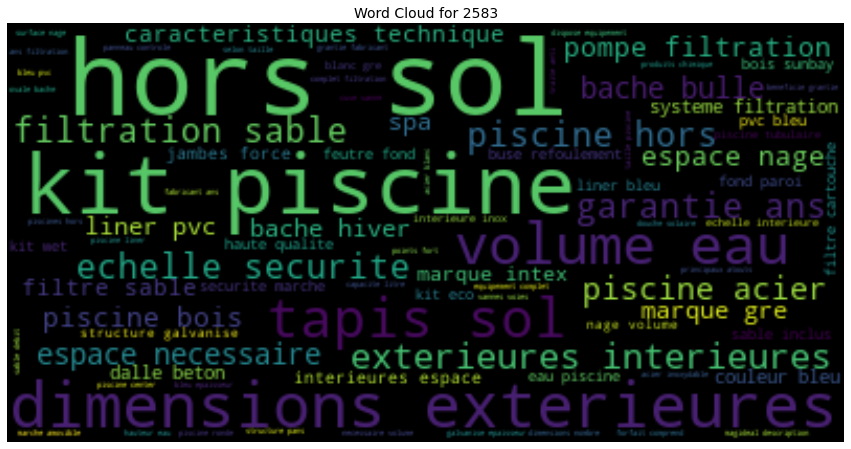

In [77]:
plot_wordcloud(2583, X_train)



 Most frequent words for category 2585:
   outil: 1.0000
   taille: 0.6927
   haute qualite: 0.6400
   eau: 0.5236
   caracteristique: 0.5200
   produit: 0.4527
   poignee: 0.4309
   pcs: 0.4164
   jardin: 0.4145
   duree vie: 0.3927


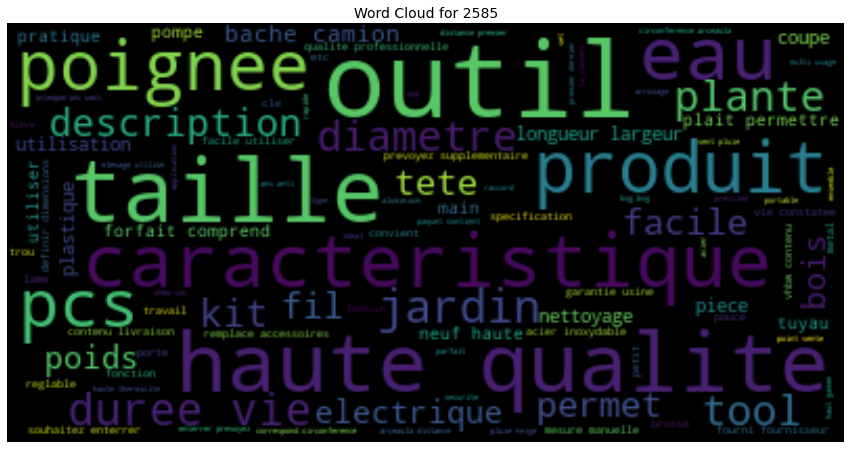

In [78]:
plot_wordcloud(2585, X_train)



 Most frequent words for category 2705:
   vie: 1.0000
   histoire: 0.7753
   homme: 0.7575
   monde: 0.7535
   livre: 0.6759
   ouvrage: 0.5209
   grand: 0.4990
   temps: 0.4950
   auteur: 0.4513
   politique: 0.4513


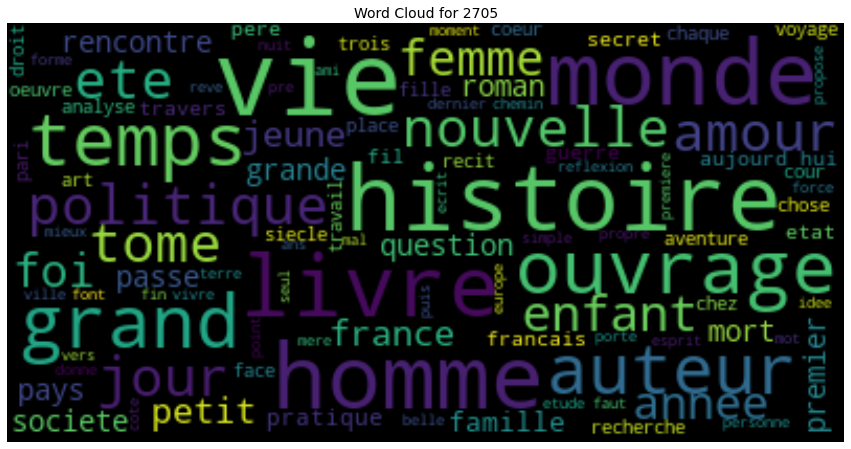

In [79]:
plot_wordcloud(2705, X_train)



 Most frequent words for category 2905:
   jeu telechargement: 1.0000
   configuration requise: 0.7275
   connexion internet: 0.6628
   telechargement note: 0.6513
   compte steam: 0.5831
   caracteristique: 0.5473
   requise windows: 0.4376
   monde: 0.3984
   propos jeu: 0.3799
   internet requise: 0.3464


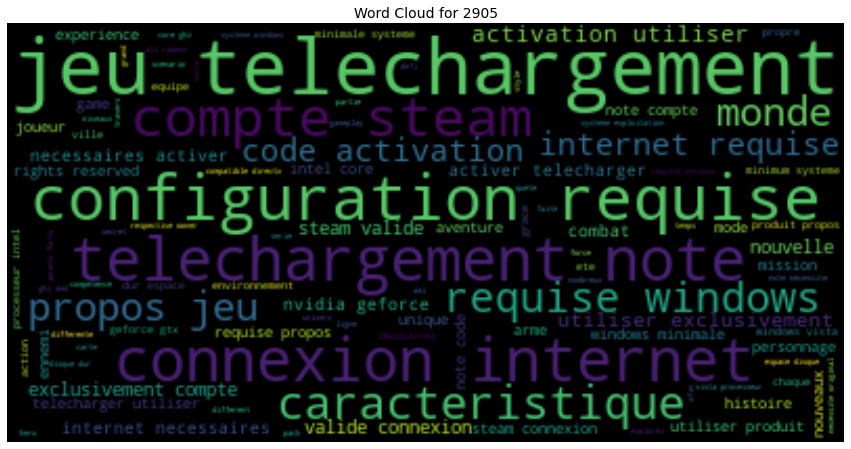

In [80]:
plot_wordcloud(2905, X_train)


### 3.5 Summary: Most Frequent Words by Product Category

In [81]:
print("\nSummary: Most Frequent Words by Product Category")
print("=" * 100)

for category, words in word_freq_dict.items():
    top_words = ", ".join([word for word, freq in words])
    print("-" * 100)
    print(f"Product Code {category:<5} | {top_words}")

print("=" * 100)



Summary: Most Frequent Words by Product Category
----------------------------------------------------------------------------------------------------
Product Code 10    | tome, edition, histoire, guide, collection, book, vie, france, art, volume
----------------------------------------------------------------------------------------------------
Product Code 40    | forfait comprend, attention produit, produit informations, informations langues, langues titres, titres apparaissent, apparaissent fiche, fiche editeur, editeur fournies, fournies neanmoins
----------------------------------------------------------------------------------------------------
Product Code 50    | manette, controleur, jeu, support, console, compatible, cable, usb, charge, haute qualite
----------------------------------------------------------------------------------------------------
Product Code 60    | console jeu, nom marque, ouiecran tactile, denumero modele, couleur ouiecran, tactile denumero, affichage c

In [82]:
dict_prdtypecode = {
    "prdtypecode": [10, 40, 50, 60, 1140, 1160, 1180, 1280, 1281, 1300, 
                    1301, 1302, 1320, 1560, 1920, 1940, 2060, 2220, 2280, 
                    2403, 2462, 2522, 2582, 2583, 2585, 2705, 2905],  
 
    "Label": ["adult books", "imported video games", "video games accessories", "games and consoles", 
              "figurines and Toy Pop", "playing cards", "figurines, masks and role playing games", 
              "toys for children", "board games", "remote controlled models", "accessories children", 
              "toys, outdoor playing, clothes", "early childhood", "interior furniture and bedding", 
              "interior accessories", "Food", "decoration interior", "supplies for domestic animals", 
              "magazines", "children books and magazines", "games", "stationery", 
              "furniture kitchen and garden", "piscine spa", "gardening and DIY", "books", 
              "online distribution of video games"]
}


### 3.6 📌 Identifying Product Category Labels from Word Cloud Analysis

By analyzing the **Word Cloud visualizations** and the **summary of most frequent words**, we were able to accurately identify the product categories associated with each `prdtypecode`. Below is the final mapping of **product categories to their respective product codes**:  

| **Product Code** | **Identified Category** |  
|-----------------|------------------------|  
| 10             | Adult Books |  
| 40             | Imported Video Games |  
| 50             | Video Games Accessories |  
| 60             | Games and Consoles |  
| 1140           | Figurines and Toy Pop |  
| 1160           | Playing Cards |  
| 1180           | Figurines, Masks, and Role-Playing Games |  
| 1280           | Toys for Children |  
| 1281           | Board Games |  
| 1300           | Remote Controlled Models |  
| 1301           | Accessories for Children |  
| 1302           | Toys, Outdoor Playing, and Clothes |  
| 1320           | Early Childhood |  
| 1560           | Interior Furniture and Bedding |  
| 1920           | Interior Accessories |  
| 1940           | Food |  
| 2060           | Decoration Interior |  
| 2220           | Supplies for Domestic Animals |  
| 2280           | Magazines |  
| 2403           | Children Books and Magazines |  
| 2462           | Games |  
| 2522           | Stationery |  
| 2582           | Furniture, Kitchen, and Garden |  
| 2583           | Piscine and Spa |  
| 2585           | Gardening and DIY |  
| 2705           | Books |  
| 2905           | Online Distribution of Video Games |  

 📌 **This mapping will be used in the next steps to add meaningful labels to our training dataset.**


#### Generating the prdtypecode → Label mapping

In [85]:
# Define the mapping of prdtypecode to category labels
dict_code_label = {
    10: "Adult Books",
    40: "Imported Video Games",
    50: "Video Games Accessories",
    60: "Games and Consoles",
    1140: "Figurines and Toy Pop",
    1160: "Playing Cards",
    1180: "Figurines, Masks, and Role-Playing Games",
    1280: "Toys for Children",
    1281: "Board Games",
    1300: "Remote Controlled Models",
    1301: "Accessories for Children",
    1302: "Toys, Outdoor Playing, and Clothes",
    1320: "Early Childhood",
    1560: "Interior Furniture and Bedding",
    1920: "Interior Accessories",
    1940: "Food",
    2060: "Decoration Interior",
    2220: "Supplies for Domestic Animals",
    2280: "Magazines",
    2403: "Children Books and Magazines",
    2462: "Games",
    2522: "Stationery",
    2582: "Furniture, Kitchen, and Garden",
    2583: "Piscine and Spa",
    2585: "Gardening and DIY",
    2705: "Books",
    2905: "Online Distribution of Video Games"
}

# #  Add the category labels to X_train
# X_train["Label"] = X_train["prdtypecode"].map(dict_code_label)

# # Display a sample to verify
# X_train.head()

# Convert the dictionary into a Pandas DataFrame for better visualization
import pandas as pd
mapping_df = pd.DataFrame(list(dict_code_label.items()), columns=["Product Code", "Identified Category"])
display(mapping_df)


,Product Code,Identified Category
0,10,Adult Books
1,40,Imported Video Games
2,50,Video Games Accessories
3,60,Games and Consoles
4,1140,Figurines and Toy Pop
5,1160,Playing Cards
6,1180,"Figurines, Masks, and Role-Playing Games"
7,1280,Toys for Children
8,1281,Board Games
9,1300,Remote Controlled Models


## 4. Saving Data for Future Use

Since `X_train.pkl`, `y_train.pkl`, and `X_test_sub.pkl` have **not been modified in this notebook**, we do **not** need to resave them.

However, we **do save the category mapping** (`prdtypecode → label`), which will be used in the next steps.

#### ✅ Already existing datasets (not modified here)
- `X_train.pkl` → Training dataset (labels will be added later).  
- `X_test_sub.pkl` → Test dataset for challenge submission (unchanged).  
- `y_train.pkl` → Target variable (will be encoded later).  

#### 📌 Saving **category mapping** for later use
- `prdtypecode_categories_mapping.pkl` → Pickle file for fast loading in the next notebook.  
- `prdtypecode_categories_mapping.csv` → CSV file for reference.    



In [89]:
import os
import pickle

# Define the directory for saving processed data
PICKLE_DIR = Path(config.PROCESSED_DIR)
os.makedirs(PICKLE_DIR, exist_ok=True)

# Convert dictionary to DataFrame
mapping_df = pd.DataFrame(list(dict_code_label.items()), columns=["prdtypecode", "Category"])

# Define file paths
mapping_csv_path = PICKLE_DIR / "prdtypecode_categories_mapping.csv"
mapping_pkl_path = PICKLE_DIR / "prdtypecode_categories_mapping.pkl"

# Save as CSV and Pickle files
mapping_df.to_csv(mapping_csv_path, index=False)
mapping_df.to_pickle(mapping_pkl_path)  

print(f"[✔] Product code mapping saved as CSV: {mapping_csv_path}")
print(f"[✔] Product code mapping saved as Pickle (DataFrame): {mapping_pkl_path}")


[✔] Product code mapping saved as CSV: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_categories_mapping.csv
[✔] Product code mapping saved as Pickle (DataFrame): D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_categories_mapping.pkl


## 5. 🔄 Next Steps

We have utilized word clouds to visualize the most frequent terms within product categories.  
This analysis allowed us to **identify and map product categories to their respective `prdtypecode` values**.  

To maintain a clean and modular pipeline, we **did not modify `X_train.pkl` in this notebook**.  
Instead, we **saved the category mapping (`prdtypecode → label`)**, which will be used in the next step.

---

### Next, we will:  

- **Load the category mapping (`prdtypecode_categories_mapping.pkl`)**.  
- **Integrate the category labels into `X_train.pkl`**.  
- **Encode `prdtypecode` as numeric values (0 to 26) for model training**.  
- **Split the trainingdataset for different tasks: Text (Machine Learning and RNN) and later for Image (CNN - Deep Learning)**.  

📌 **All these steps will be performed in** `06_Data_Labeling_and_Preprocessing.ipynb`.  

➡️ **Let's proceed to the next notebook to continue preparing our dataset! 🚀**

